In [136]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("whitegrid")

import sklearn

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import BayesianRidge

In [40]:
import numpy as np
import pandas as pd

# Фиксируем сид для воспроизводимости
np.random.seed(42)

# Размер датасета
n_samples = 1000

# 1. Возраст (Age): от 30 до 80 лет
age = np.random.uniform(30, 80, n_samples)

# 2. Холестерин общий (Total_Cholesterol): зависит от возраста + шум
total_chol = 150 + 0.5 * age + np.random.normal(0, 20, n_samples)

# 3. Холестерин ЛПНП (LDL): мультиколлинеарен с общим (r ~ 0.85)
ldl = 0.85 * total_chol + np.random.normal(0, 0.02, n_samples)

# 4. ИМТ (BMI): от 18 до 45
bmi = np.random.uniform(18, 45, n_samples)

# 5. Систолическое давление (Systolic_BP): зависит от возраста и ИМТ + шум
systolic_bp = 100 + 0.3 * age + 0.5 * bmi + np.random.normal(0, 10, n_samples)

# 6. Курение (Smoker): бинарный, ~30% курящих
smoker = np.random.binomial(1, 0.3, n_samples)

# Таргет: вероятность инфаркта (Heart_Attack_Risk)
# Логистическая функция от линейной комбинации предикторов
log_odds = (
    -12
    + 0.04 * age
    + 0.02 * total_chol
    + 0.015 * ldl
    + 0.05 * bmi
    + 0.03 * systolic_bp
    + 1.5 * smoker
)
heart_attack_risk = 1 / (1 + np.exp(-log_odds))

# Формируем DataFrame
data = pd.DataFrame({
    'Age': np.round(age).astype(int),
    'Total_Cholesterol': total_chol,
    'LDL': ldl,
    'BMI': bmi,
    'Systolic_BP': systolic_bp,
    'Smoker': smoker,
    'Heart_Attack_Risk': heart_attack_risk
})

# Сохраняем в CSV
data.to_csv('heart_attack_data.csv', index=False)

print("Датасет сгенерирован! Первые 5 строк:")
print(data.head())
print(f"\nФорма: {data.shape}")
print(f"Корреляция Total_Cholesterol и LDL: {data['Total_Cholesterol'].corr(data['LDL']):.2f}")


Датасет сгенерирован! Первые 5 строк:
   Age  Total_Cholesterol         LDL        BMI  Systolic_BP  Smoker  \
0   49         177.917523  151.201768  25.515949   119.056527       0   
1   78         162.060970  137.750163  39.553916   136.654845       1   
2   67         190.903806  162.238140  26.808856   125.230581       0   
3   60         192.178177  163.366652  26.083351   120.359203       0   
4   38         180.096275  153.083483  24.277662   144.726825       0   

   Heart_Attack_Risk  
0           0.650889  
1           0.981769  
2           0.882155  
3           0.832900  
4           0.724302  

Форма: (1000, 7)
Корреляция Total_Cholesterol и LDL: 1.00


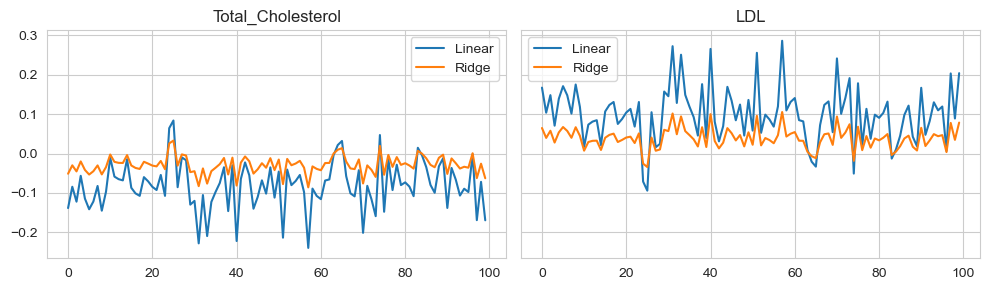

In [150]:
X = data.drop(columns = ['Heart_Attack_Risk'])
y = data['Heart_Attack_Risk']

coef_df_lr = pd.DataFrame(columns = data.columns[:-1])
coef_df_ridge = pd.DataFrame(columns = data.columns[:-1])

for k in range(100):
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)#, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)
    d = pd.DataFrame(index = data.columns[:-1], data = model.coef_).T
    coef_df_lr = pd.concat([coef_df_lr, d], ignore_index=True)
    
    model = Ridge(0.25)
    model.fit(X_train, y_train)
    d = pd.DataFrame(index = data.columns[:-1], data = model.coef_).T
    coef_df_ridge = pd.concat([coef_df_ridge, d], ignore_index=True)
    
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 3), sharey=True)

ax[0].plot(coef_df_lr['Total_Cholesterol'], color = 'C0', label = 'Linear')
ax[0].plot(coef_df_ridge['Total_Cholesterol'], color = 'C1', label = 'Ridge')
ax[0].set_title('Total_Cholesterol')
ax[0].legend()

ax[1].plot(coef_df_lr['LDL'], color = 'C0', label = 'Linear')
ax[1].plot(coef_df_ridge['LDL'], color = 'C1', label = 'Ridge')
ax[1].set_title('LDL')
ax[1].legend()

plt.tight_layout()
plt.show()

In [152]:
# data.to_csv('data/heart_attack.csv', index=False)